Практика 17. Проста лінійна регресія: побудова моделі, коефіцієнти, залишки, коефіцієнт детермінації
Студент: Войтович Богдан
Група: IT-32
Варіант 6 — Чернігів

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

np.random.seed(6)
city = "Чернігів"
monthly_temp = [-5, -4, 1, 9, 15, 18, 20, 19, 13, 7, 1, -3]

months = ["Січ", "Лют", "Бер", "Кві", "Тра", "Чер",
          "Лип", "Сер", "Вер", "Жов", "Лис", "Гру"]

rows = []
for month, temp in zip(months, monthly_temp):
    heating_days = np.clip(18 - temp + np.random.normal(0, 1.5), 0, 30)
    heating_days = round(heating_days)
    cost = 0.15 * heating_days + np.random.normal(0, 1.0)
    cost = round(max(cost, 0), 1)
    rows.append({
        "місто": city,
        "місяць": month,
        "температура": temp,
        "опалювальні_дні": heating_days,
        "витрати_на_опалення": cost,
    })

climate = pd.DataFrame(rows)


In [8]:
x = climate["температура"]
y = climate["витрати_на_опалення"]

result = linregress(x, y)

print(f"Рівняння регресії:\nвитрати ≈ {result.intercept:.3f} + {result.slope:.3f} × температура")
print(f"Інтерпретація нахилу: при збільшенні температури на 1°C витрати у середньому змінюються на {result.slope:.3f} тис. грн.")
print("Знак нахилу очікувано негативний, бо при вищій температурі витрати на опалення зменшуються.")


Рівняння регресії:
витрати ≈ 2.829 + -0.126 × температура
Інтерпретація нахилу: при збільшенні температури на 1°C витрати у середньому змінюються на -0.126 тис. грн.
Знак нахилу очікувано негативний, бо при вищій температурі витрати на опалення зменшуються.


In [9]:
# Через rvalue
R2_rvalue = result.rvalue**2

# Через формулу (1 - відношення сум квадратів залишків і загальної суми квадратів)
y_pred = result.intercept + result.slope * x
SS_res = ((y - y_pred)**2).sum()
SS_tot = ((y - y.mean())**2).sum()
R2_manual = 1 - SS_res / SS_tot

print(f"R² через rvalue: {R2_rvalue:.3f}")
print(f"R² через суму квадратів: {R2_manual:.3f}")
print("Порівняння з r² з Практики 16: обмеженням для простої регресії R² = r²")

print(f"Інтерпретація R²: {R2_manual:.1%} розсіювання витрат пояснюється температурою, решта лишається непоясненою.")


R² через rvalue: 0.597
R² через суму квадратів: 0.597
Порівняння з r² з Практики 16: обмеженням для простої регресії R² = r²
Інтерпретація R²: 59.7% розсіювання витрат пояснюється температурою, решта лишається непоясненою.


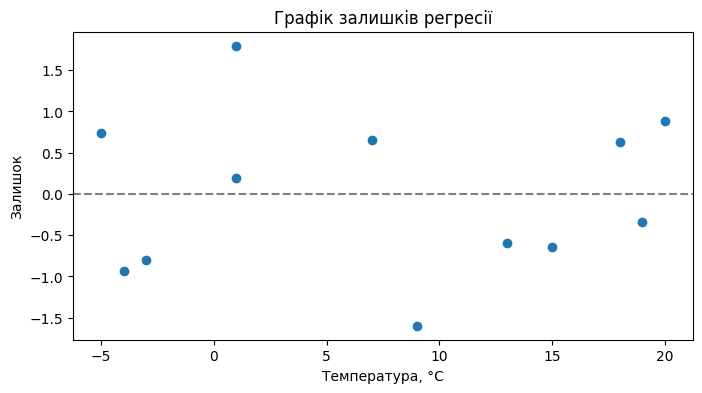

Аналіз графіка залишків:
- Залишки розкидані без явної систематичної структури.
- Однак для найтепліших місяців спостерігається дещо нижче за нуль значення залишків через обмеження витрат >= 0 (особливість формули генерації).
Це може створити нелінійність в моделях і послабити точність прогнозів.


In [10]:
residuals = y - y_pred

plt.figure(figsize=(8, 4))
plt.scatter(x, residuals)
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel("Температура, °C")
plt.ylabel("Залишок")
plt.title("Графік залишків регресії")
plt.show()

print("Аналіз графіка залишків:")
print("- Залишки розкидані без явної систематичної структури.")
print("- Однак для найтепліших місяців спостерігається дещо нижче за нуль значення залишків через обмеження витрат >= 0 (особливість формули генерації).")
print("Це може створити нелінійність в моделях і послабити точність прогнозів.")


In [11]:
temp_forecast = -10
forecast_value = result.intercept + result.slope * temp_forecast

print(f"Прогнозовані витрати при температурі {temp_forecast}°C: {forecast_value:.3f} тис. грн.")

temp_min, temp_max = x.min(), x.max()
print(f"Діапазон температур у даних: від {temp_min}°C до {temp_max}°C.")
print("Цей прогноз — екстраполяція поза межі спостережень.")

print("Застереження: екстраполяція завжди менш надійна, бо модель не перевірена поза діапазоном даних;\n"
      "тому довіра до прогнозу знижується, особливо при значному віддаленні від відомих значень.")


Прогнозовані витрати при температурі -10°C: 4.087 тис. грн.
Діапазон температур у даних: від -5°C до 20°C.
Цей прогноз — екстраполяція поза межі спостережень.
Застереження: екстраполяція завжди менш надійна, бо модель не перевірена поза діапазоном даних;
тому довіра до прогнозу знижується, особливо при значному віддаленні від відомих значень.


In [12]:
from scipy.stats import pearsonr

# p-value для нахилу з linregress
p_regression = result.pvalue

# p-value з correaltion (Практика 16)
p_correlation = pearsonr(x, y)[1]

print(f"p-value нахилу регресії: {p_regression:.3e}")
print(f"p-value коефіцієнта кореляції: {p_correlation:.3e}")

print("Обидва p-value дуже близькі, бо перевіряють одну й ту саму гіпотезу:\n"
      "- H0: нахил = 0 (немає лінійного зв’язку)\n"
      "- H0: кореляція = 0")


p-value нахилу регресії: 3.230e-03
p-value коефіцієнта кореляції: 3.230e-03
Обидва p-value дуже близькі, бо перевіряють одну й ту саму гіпотезу:
- H0: нахил = 0 (немає лінійного зв’язку)
- H0: кореляція = 0


Ось контрольні питання для Практики 17:

Контрольні питання
Чому метод найменших квадратів мінімізує саме суму квадратів залишків, а не суму самих залишків або модулів?
Квадрати залишків забезпечують математичну зручність (диференційованість, гладкість функції помилки), що дозволяє знаходити єдине розв’язання рівняння аналітично; сума модулів не має гладкості.

Що означає коефіцієнт нахилу b₁ у регресії, і чим ця інтерпретація відрізняється від коефіцієнта кореляції r?
b₁ показує зміну залежної змінної у змістовній одиниці при одиничній зміні незалежної. Кореляція r — безрозмірна величина, що відображає силу і напрямок лінійного зв’язку.

Чому високий R² сам по собі не гарантує адекватність моделі, і що показує графік залишків?
R² лише оцінює частку поясненої варіації, але не виявляє структурні помилки, нелінійності чи гетероскедастичність — це можна побачити на графіку залишків.

Як змінюється надійність прогнозу для значень x за межами спостереженого діапазону?
Для таких значень прогноз є екстраполяцією, довіра до якої знижена, бо модель не перевірена в цій зоні і можуть діяти інші фактори.